In [1]:
import pandas as pd
cbe_df = pd.read_csv('../data/processed/commercial_bank_of_ethiopia_cleaned_reviews.csv')
cbe_df.head()

,review,rating,date,bank,source
0,More than garrantty bank EBC.,4,2025-06-07,Commercial Bank of Ethiopia,Google Play
1,really am happy to this app it is Siple to use...,5,2025-06-07,Commercial Bank of Ethiopia,Google Play
2,I liked this app. But the User interface is ve...,2,2025-06-07,Commercial Bank of Ethiopia,Google Play
3,"""Why don’t your ATMs support account-to-accoun...",4,2025-06-06,Commercial Bank of Ethiopia,Google Play
4,what is this app problem???,1,2025-06-05,Commercial Bank of Ethiopia,Google Play


In [2]:
# Number of rows and columns
print("Shape:", cbe_df.shape)

# Column types and non-null counts
print("\nInfo:")
print(cbe_df.info())

# Check for missing values
print("\nMissing values:")
print(cbe_df.isnull().sum())


Shape: (414, 5)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  414 non-null    object
 1   rating  414 non-null    int64 
 2   date    414 non-null    object
 3   bank    414 non-null    object
 4   source  414 non-null    object
dtypes: int64(1), object(4)
memory usage: 16.3+ KB
None

Missing values:
review    0
rating    0
date      0
bank      0
source    0
dtype: int64


In [3]:
# Check for duplicates
print("Duplicates:", cbe_df.duplicated().sum())

# Drop duplicates (if any)
cbe_df.drop_duplicates(inplace=True)

# Quick summary of ratings
print("\nRatings summary:")
print(cbe_df['rating'].describe())


Duplicates: 0

Ratings summary:
count    414.000000
mean       3.828502
std        1.578321
min        1.000000
25%        3.000000
50%        5.000000
75%        5.000000
max        5.000000
Name: rating, dtype: float64


Visualize Ratings Distribution

C:\Users\PC\AppData\Local\Temp\ipykernel_21644\1535618868.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=cbe_df, palette='viridis')


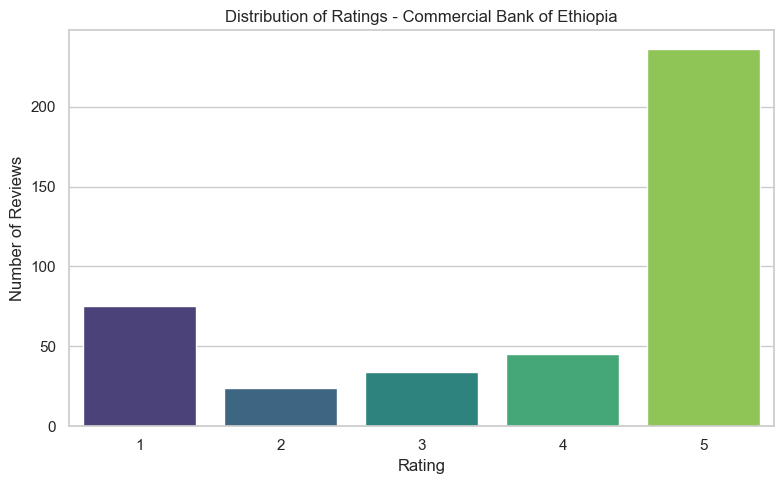

In [5]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Plot histogram
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=cbe_df, palette='viridis')
plt.title('Distribution of Ratings - Commercial Bank of Ethiopia')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()


Average Rating Over Time

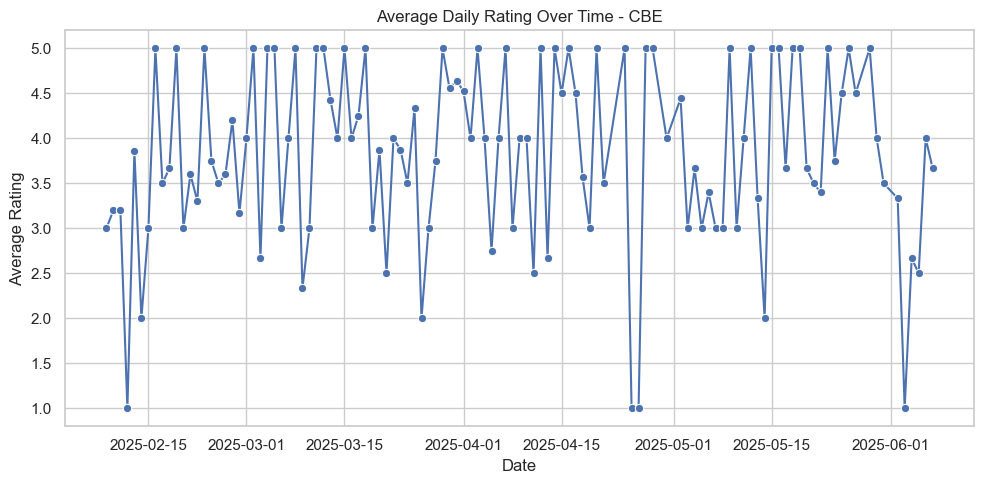

In [7]:
# Convert date column to datetime if not already
cbe_df['date'] = pd.to_datetime(cbe_df['date'])

# Group by date and compute mean rating
daily_avg = cbe_df.groupby('date')['rating'].mean().reset_index()

# Plot the trend
plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_avg, x='date', y='rating', marker='o')
plt.title('Average Daily Rating Over Time - CBE')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()


Plot daily Review Counts: This helps reveal how many users left reviews per day (regardless of rating), highlighting spikes or dips in engagement.

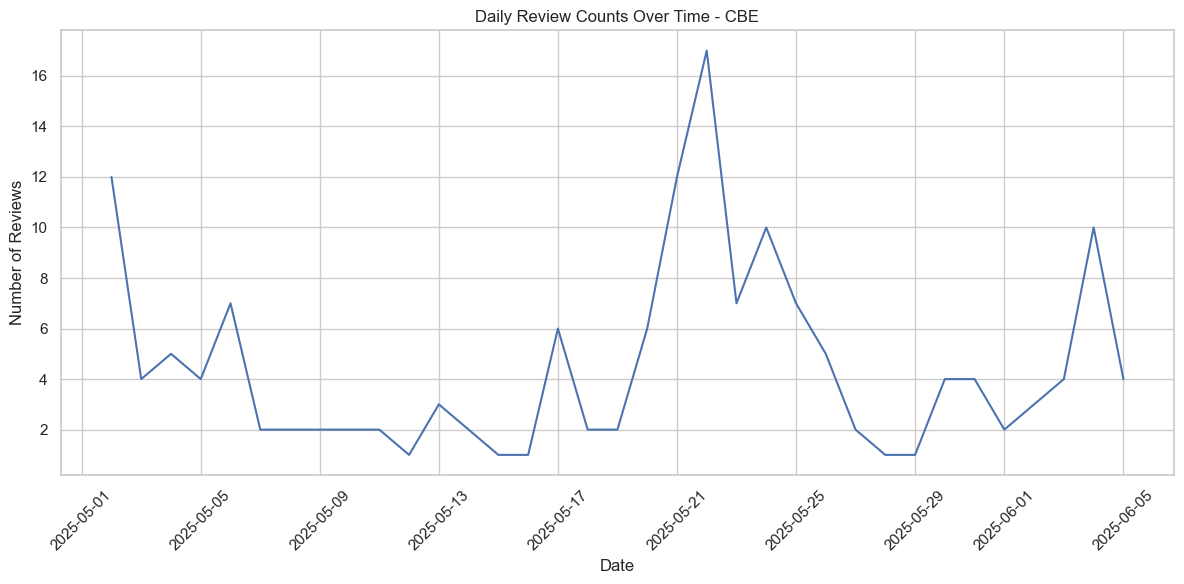

In [15]:
# Group by date and count reviews
daily_review_counts = cbe_df.groupby('date').size()

# Plot daily review counts
plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_review_counts.index, y=daily_review_counts.values)
plt.title('Daily Review Counts Over Time - CBE')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Analyze 1-Star Reviews: isolate 1-star reviews and see what users are complaining about.

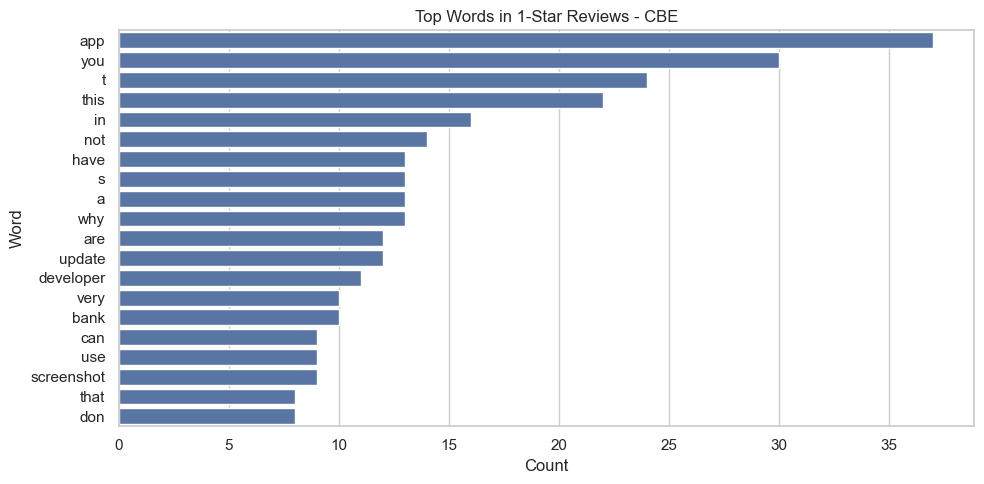

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# If your CSV file is loaded like this
df = pd.read_csv('../data/processed/commercial_bank_of_ethiopia_cleaned_reviews.csv') # or however you loaded your data
df['date'] = pd.to_datetime(df['date'])  # ensure date column is datetime format
# Filter 1-star reviews
one_star_reviews = df[df['rating'] == 1]

# Check most common words (basic version)
from collections import Counter
import re

# Combine all reviews into one string
all_text = " ".join(one_star_reviews['review'].dropna().astype(str))

# Tokenize and clean
words = re.findall(r'\b\w+\b', all_text.lower())
filtered_words = [word for word in words if word not in ['the', 'is', 'and', 'to', 'i', 'it', 'was', 'for', 'of']]  # stop words

# Count top words
word_freq = Counter(filtered_words).most_common(20)

# Convert to DataFrame and plot
word_df = pd.DataFrame(word_freq, columns=['word', 'count'])

plt.figure(figsize=(10, 5))
sns.barplot(x='count', y='word', data=word_df)
plt.title('Top Words in 1-Star Reviews - CBE')
plt.xlabel('Count')
plt.ylabel('Word')
plt.tight_layout()
plt.show()


In [10]:
df.to_csv("clean_cbe_reviews.csv", index=False)
